In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import xgcm
import matplotlib.pyplot as plt
import xbudget

from load_example_ecco_grid import * 
from eccov4r4_budget_diagnostics import * 
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)

xarray: 2025.8.0
xgcm: 0.10.0


## Tutorial: ECCO V4r4 example
This tutorial gives a compact introduction to the ECCO V4r4 budget diagnostics and shows how to use `xbudget` to assemble and verify mass, heat, and salt budgets on the LLC grid.

### Load example ECCO V4r4 dataset from Zenodo
The example loader returns an `xgcm.Grid` object together with the underlying ECCO dataset in `grid._ds`.

In [3]:
grid = load_ECCOV4r4_coarsened_diagnostics() # this takes about 7 minutes

# Build a time-step coordinate and a cell-volume metric used repeatedly below.
dt = grid._ds["time_bounds"].diff("time_bounds").rename({"time_bounds":"time"})

grid._ds = grid._ds.assign_coords(
    {"dt":("time", dt.dt.total_seconds().values), 
    "volcello": (grid._ds["drF"] * grid._ds["hFacC"]) * grid._ds["rA"]
    }
)

File 'ECCO_budget_terms.nc' already exists at ../data/ECCO_budget_terms.nc. Skipping download.


### Preprocess standard ECCO diagnostics 
The ECCO V4r4 fields hosted on PO.DAAC contain the ingredients needed to close native-grid mass, heat, and salt budgets, but a few terms need to be reorganized before they match the bookkeeping expected by `xbudget`. In particular, some diagnostics combine interior and boundary contributions, while others separate penetrative and non-penetrative surface forcing.

In [4]:
def zero_top_layer(ds, varname = "", zdim = "k_l"):
    # Remove the surface layer contribution when a diagnostic should only represent interior transport.
    return xr.where(ds[f"{zdim}"] != ds[f"{zdim}"].isel({f"{zdim}":0}),ds[varname].copy(),0.0,)
def make_flux_3d(ds, varname = "", zdim = "k"):
    # Broadcast a surface flux into a 3D array that only occupies the top model layer.
    k  = ds[f"{zdim}"]
    return xr.where(k == k.isel({f"{zdim}":0}), ds[varname].copy().expand_dims({f"{zdim}":k}),0.0,)

# Assemble ECCO heat-flux terms into the budget components expected by xbudget.
grid._ds["geothermal_heat_flux_convergence"] = eccov4r4_geothermal_heat_flux_tendency(grid._ds) 
grid._ds["pen_boundary_forcing_heat_tendency"] = eccov4r4_penetrative_heat_flux_tendency(grid._ds)
grid._ds["nonpen_boundary_forcing_heat_tendency"] = eccov4r4_nonpenetrative_heat_flux_tendency(grid._ds)
grid._ds["boundary_forcing_heat_tendency"] = grid._ds["pen_boundary_forcing_heat_tendency"] + grid._ds["nonpen_boundary_forcing_heat_tendency"]

# Put the sea-ice salt exchange and salt-plume tendency onto the same vertical grid.
SFLUX = grid._ds["SFLUX"].assign_coords(k=0).expand_dims(dim='k',axis=1) # sea-ice salt exchange
grid._ds["boundary_forcing_salt_tendency"] = xr.concat([SFLUX+grid._ds["oceSPtnd"],grid._ds["oceSPtnd"].isel(k=slice(1,None))], dim='k') # combine surface salt flux and plume tendency

# Separate interior vertical transport from the freshwater boundary forcing term.
grid._ds["WVELMASS_interior"] = zero_top_layer(grid._ds, varname = "WVELMASS", zdim = "k_l") #
grid._ds["boundary_forcing_volume_tendency"] = make_flux_3d(grid._ds, varname = "oceFWflx", zdim = "k")

# Rechunk once before calling xbudget so later difference and convergence steps stay tractable.
grid._ds = grid._ds.chunk({"tile":2, "i":50, "j":50, "i_g":50, "j_g":50, "k": 10}).fillna(0.0)
# to-do: add comparable chunking inside the difference and convergence routines 

### Load budget metadata from the ECCO preset dictionary
This preset tells `xbudget` which variables belong on the left-hand side, which belong on the right-hand side, and how derived budget terms should be combined.

In [5]:
# Load the preset metadata dictionary and let xbudget attach the derived budget terms.
recipe = xbudget.load_preset_budget(model="ECCOV4r4_native").copy()
xbudget.collect_budgets(grid, recipe, allow_rechunk=True)
q = xbudget.BudgetQuery(grid, recipe)
# Aggregate the full metadata tree into a simpler budget summary for inspection.
simple_budgets = q.aggregate()
simple_budgets

/Users/hfdrake/code/wt-xbudget-pr26/xbudget/evaluate.py:251: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/hfdrake/code/wt-xbudget-pr26/xbudget/evaluate.py:251: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/hfdrake/code/wt-xbudget-pr26/xbudget/evaluate.py:251: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/hfdrake/code/wt-xbudget-pr26/xbudget/evaluate.py:251: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/hfdrake/code/wt-xbudget-pr26/xbudget/evaluate.py:251: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


...

/Users/hfdrake/code/wt-xbudget-pr26/xbudget/collect.py:137: UserWarning: Summing terms with mismatched dimensions while building 'heat_rhs': the operands carry dimension sets [('i', 'j', 'k', 'tile', 'time'), ('i', 'j', 'k', 'tile', 'time'), ('i', 'j', 'k', 'tile', 'time'), ('i', 'j', 'k', 'tile')]. xarray will broadcast the lower-dimensional term(s) across ('time',), e.g. spreading a 2D surface flux uniformly over the vertical of a 3D flux convergence instead of depositing it at the outcropping level. Verify this broadcast is intended; see https://github.com/hdrake/xbudget/issues/11.
  warnings.warn(


/Users/hfdrake/code/wt-xbudget-pr26/xbudget/evaluate.py:251: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/hfdrake/code/wt-xbudget-pr26/xbudget/evaluate.py:251: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


/Users/hfdrake/code/wt-xbudget-pr26/xbudget/evaluate.py:251: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(
/Users/hfdrake/code/wt-xbudget-pr26/xbudget/evaluate.py:251: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn(


{'mass': {'lambda': 'density',
  'thickness': 'thkcello',
  'lhs': {'Eulerian_tendency': 'mass_lhs_Eulerian_tendency'},
  'rhs': {'advection': 'mass_rhs_advection',
   'surface_exchange_flux': 'mass_rhs_surface_exchange_flux'}},
 'heat': {'lambda': 'THETA',
  'lhs': {'Eulerian_tendency': 'heat_lhs_Eulerian_tendency'},
  'rhs': {'advection': 'heat_rhs_advection',
   'diffusion': 'heat_rhs_diffusion',
   'surface_exchange_flux': 'heat_rhs_surface_exchange_flux',
   'bottom_flux': 'heat_rhs_bottom_flux'}},
 'salt': {'lambda': 'SALT',
  'lhs': {'Eulerian_tendency': 'salt_lhs_Eulerian_tendency'},
  'rhs': {'advection': 'salt_rhs_advection',
   'diffusion': 'salt_rhs_diffusion',
   'surface_exchange_flux': 'salt_rhs_surface_exchange_flux'}}}

### Verify that the budgets close

The checks below compare the left-hand-side (LHS) storage tendency against the diagnosed sum of the right-hand-side (RHS) source, sink, and flux-convergence terms. We look at both spatial patterns and globally averaged time series. Because ECCO uses the LLC grid, the maps are first remapped to a regular latitude-longitude grid for quick visualization.

Refer to `MOM6_budget_examples_mass_heat_salt.ipynb` for a more detailed explanation of the `xbudget` workflow.

In [6]:
def plot_interpolated_ecco(fig, ax, ds, vmin=0, vmax=30, cmap="coolwarm"):
    # Build a simple regular lat-lon target grid for quick visual comparison.
    target_lon = np.arange(-180, 180, 1)
    target_lat = np.arange(-90, 90, 1)
    lon_grid, lat_grid = np.meshgrid(target_lon, target_lat)
    
    # Flatten the LLC field into point/value pairs for interpolation.
    points = np.column_stack((ds.XC.values.ravel(), ds.YC.values.ravel()))
    values = ds.values.ravel()
    
    # Use nearest-neighbor remapping to preserve the native diagnostic values.
    interpolated_data = griddata(points, values, (lon_grid, lat_grid), method='nearest')
    
    # Plot the remapped field.
    cb = ax.pcolormesh(lon_grid, lat_grid, interpolated_data, 
                       vmin=vmin, vmax=vmax, cmap=cmap)
    
    return cb

### Volume budgets
This first check verifies that the vertically integrated volume tendency is balanced by the diagnosed transport and boundary-forcing terms.

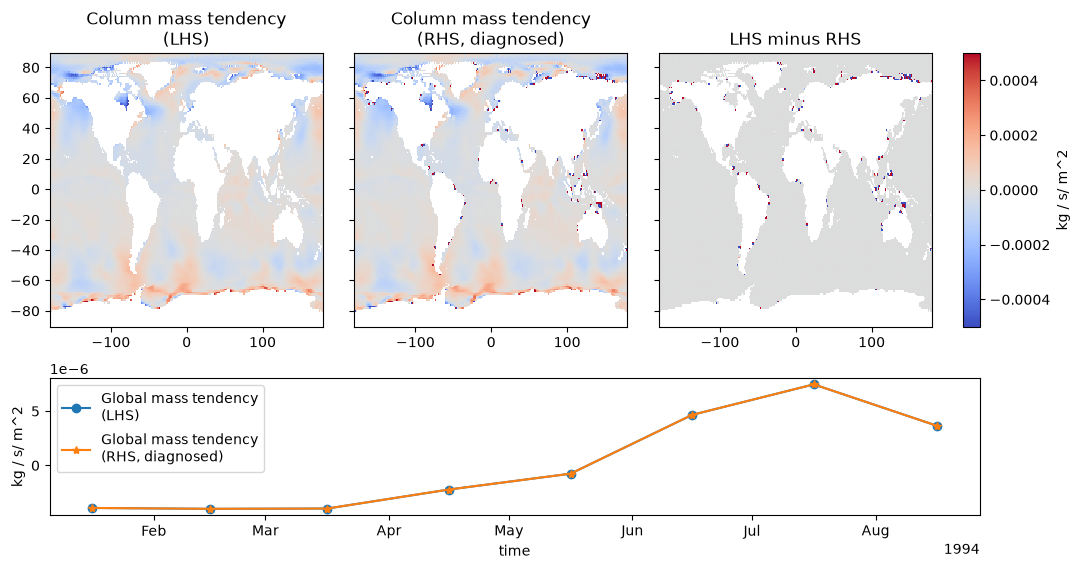

In [7]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1,  0.06], height_ratios=[1, 0.5], hspace=0.25, wspace=0.15)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0); ax1.tick_params(labelleft=False)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0); ax2.tick_params(labelleft=False)
cax = fig.add_subplot(gs[0, 3])
ax_bottom = fig.add_subplot(gs[1, :])

# Restrict horizontal area to wet points before forming column integrals.
area = grid._ds["rA"].where(grid._ds["Depth"] > 0.0)

# Convert native volume-integrated tendencies into column tendencies per unit area.
lhs_tendency = (grid._ds[q.var("mass_lhs")] / area).sum("k") # convert from kg/s to kg / s/ m^2
lhs_tendency = lhs_tendency.where(np.abs(lhs_tendency) > 0.0)

rhs_tendency = (grid._ds[q.var("mass_rhs")] / area).sum("k")
rhs_tendency = rhs_tendency.where(np.abs(rhs_tendency) > 0.0)

# Residual should be small if the budget closes.
tendency_difference = lhs_tendency - rhs_tendency

vmax = 5e-4
plot_interpolated_ecco(fig, ax0, lhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax0.set_title("Column mass tendency\n(LHS)")
plot_interpolated_ecco(fig, ax1, rhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax1.set_title("Column mass tendency\n(RHS, diagnosed)")
cb = plot_interpolated_ecco(fig, ax2, tendency_difference.isel(time=0), vmin=-vmax, vmax=vmax); ax2.set_title("LHS minus RHS")
fig.colorbar(cb, cax=cax, orientation="vertical", label = "kg / s/ m^2")

# Area-weighted global means summarize the closure error over time.
((lhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "o", label = "Global mass tendency\n(LHS)")
((rhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "*", label = "Global mass tendency\n(RHS, diagnosed)")
ax_bottom.set_ylabel("kg / s/ m^2")
ax_bottom.legend()

### Heat budgets
This check compares the column-integrated heat tendency against the assembled surface and transport contributions.

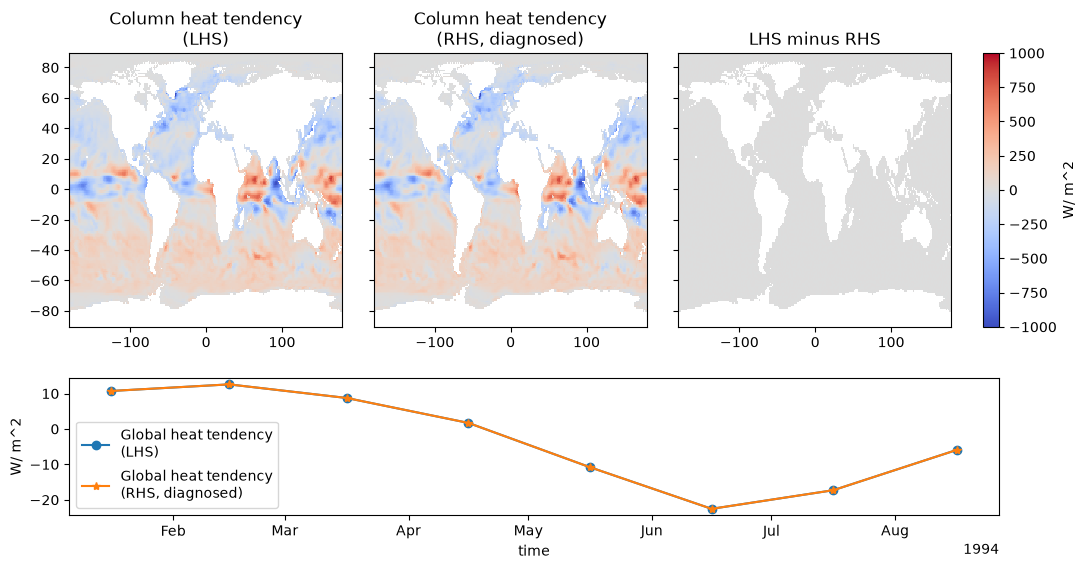

In [8]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1,  0.06], height_ratios=[1, 0.5], hspace=0.25, wspace=0.15)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0); ax1.tick_params(labelleft=False)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0); ax2.tick_params(labelleft=False)
cax = fig.add_subplot(gs[0, 3])
ax_bottom = fig.add_subplot(gs[1, :])

# Restrict horizontal area to wet points before forming column integrals.
area = grid._ds["rA"].where(grid._ds["Depth"] > 0.0)

# Convert native volume-integrated heat tendencies into column tendencies per unit area.
lhs_tendency = (grid._ds[q.var("heat_lhs")] / area).sum("k") # convert from J/s to W/m^2
lhs_tendency = lhs_tendency.where(np.abs(lhs_tendency) > 0.0)

rhs_tendency = (grid._ds[q.var("heat_rhs")] / area).sum("k")
rhs_tendency = rhs_tendency.where(np.abs(rhs_tendency) > 0.0)

# Residual should be small if the budget closes.
tendency_difference = lhs_tendency - rhs_tendency

vmax = 1000
plot_interpolated_ecco(fig, ax0, lhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax0.set_title("Column heat tendency\n(LHS)")
plot_interpolated_ecco(fig, ax1, rhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax1.set_title("Column heat tendency\n(RHS, diagnosed)")
cb = plot_interpolated_ecco(fig, ax2, tendency_difference.isel(time=0), vmin=-vmax, vmax=vmax); ax2.set_title("LHS minus RHS")
fig.colorbar(cb, cax=cax, orientation="vertical", label = "W/ m^2")

# Area-weighted global means summarize the closure error over time.
((lhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "o", label = "Global heat tendency\n(LHS)")
((rhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "*", label = "Global heat tendency\n(RHS, diagnosed)")
ax_bottom.set_ylabel("W/ m^2")
ax_bottom.legend()

### Salt budgets
This final check compares the column-integrated salt tendency against the diagnosed salt sources, sinks, and transport terms.

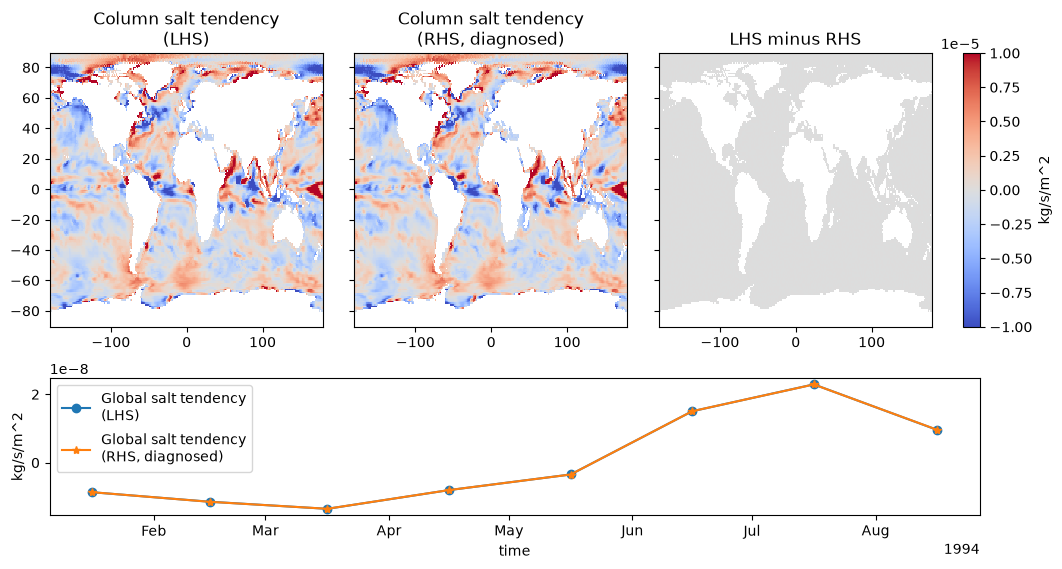

In [9]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1,  0.06], height_ratios=[1, 0.5], hspace=0.25, wspace=0.15)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0); ax1.tick_params(labelleft=False)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0); ax2.tick_params(labelleft=False)
cax = fig.add_subplot(gs[0, 3])
ax_bottom = fig.add_subplot(gs[1, :])

# Restrict horizontal area to wet points before forming column integrals.
area = grid._ds["rA"].where(grid._ds["Depth"] > 0.0)

# Convert native volume-integrated salt tendencies into column tendencies per unit area.
lhs_tendency = (grid._ds[q.var("salt_lhs")] / area).sum("k") # convert from kg/s to kg/s/m^2
lhs_tendency = lhs_tendency.where(np.abs(lhs_tendency) > 0.0)

rhs_tendency = (grid._ds[q.var("salt_rhs")] / area).sum("k")
rhs_tendency = rhs_tendency.where(np.abs(rhs_tendency) > 0.0)

# Residual should be small if the budget closes.
tendency_difference = lhs_tendency - rhs_tendency

vmax = 1e-5
plot_interpolated_ecco(fig, ax0, lhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax0.set_title("Column salt tendency\n(LHS)")
plot_interpolated_ecco(fig, ax1, rhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax1.set_title("Column salt tendency\n(RHS, diagnosed)")
cb = plot_interpolated_ecco(fig, ax2, tendency_difference.isel(time=0), vmin=-vmax, vmax=vmax); ax2.set_title("LHS minus RHS")
fig.colorbar(cb, cax=cax, orientation="vertical", label = "kg/s/m^2")

# Area-weighted global means summarize the closure error over time.
((lhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "o", label = "Global salt tendency\n(LHS)")
((rhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "*", label = "Global salt tendency\n(RHS, diagnosed)")
ax_bottom.set_ylabel("kg/s/m^2")
ax_bottom.legend()